In [4]:
import pandas as pd

# 1. Đọc dữ liệu gốc
file_path = r'D:\Study\AiTa_Lab_Research\Data_test\TP53.csv' # Nhớ thay đổi đường dẫn khớp với máy của bạn
df = pd.read_csv(file_path)

print(f"Tổng số biến thể ban đầu: {len(df)}")

# 2. Xóa các dòng không có điểm số (NaN)
df = df.dropna(subset=['score'])

# 3. Tạo hàm gán nhãn dựa trên ngưỡng chính xác từ biểu đồ
def assign_label(score):
    if score <= 20.0:
        return 'patho'
    elif score >= 75.0:
        return 'benign'
    else:
        return 'unknown' # Khoảng giữa (partially functional) sẽ bị loại bỏ

df['label'] = df['score'].apply(assign_label)

# 4. Lọc bỏ các biến thể 'unknown' để tránh nhiễu cho mô hình
df_clean = df[df['label'] != 'unknown'].copy()

# 5. Giữ lại các cột cần thiết cho chặng tiếp theo (dùng hgvs_pro)
final_df = df_clean[['label', 'hgvs_pro', 'score']]

# Xuất ra file mới
final_df.to_csv('TP53_labeled_for_API.csv', index=False)

print(f"Số biến thể sau khi lọc nhãn (Patho/Benign): {len(final_df)}")
print("Phân bố nhãn:")
print(final_df['label'].value_counts())
print("\n5 dòng đầu tiên của file chuẩn bị cho API:")
print(final_df.head())

Tổng số biến thể ban đầu: 2314
Số biến thể sau khi lọc nhãn (Patho/Benign): 1733
Phân bố nhãn:
label
benign    1240
patho      493
Name: count, dtype: int64

5 dòng đầu tiên của file chuẩn bị cho API:
    label     hgvs_pro  score
0   patho  p.Ala119Asp  14.45
3  benign  p.Ala119Ser  92.40
4  benign  p.Ala119Thr  97.35
6  benign  p.Ala129Asp  92.00
7  benign  p.Ala129Gly  82.05


In [5]:
import pandas as pd
import requests
import json
import time

# 1. Đọc dữ liệu từ Chặng 1
df = pd.read_csv('TP53_labeled_for_API.csv')

# 2. Ghép mã Transcript chuẩn của TP53 với hgvs_pro để thực hiện dịch ngược
# VD: ENST00000269305:p.Ala119Asp
df['hgvs_query'] = 'ENST00000269305:' + df['hgvs_pro']
queries = df['hgvs_query'].dropna().unique().tolist()

# 3. Chuẩn bị thông số VEP API
server = "https://rest.ensembl.org"
ext = "/vep/human/hgvs"
headers = {
    "Content-Type": "application/json", 
    "Accept": "application/json"
}

# 4. Gửi request theo từng lô (batch) 200 đột biến
chunk_size = 200
vep_results = []

print(f"Bắt đầu truy vấn VEP API dịch ngược cho {len(queries)} đột biến TP53...")

for i in range(0, len(queries), chunk_size):
    chunk = queries[i : i + chunk_size]
    data = {"hgvs_notations": chunk}
    
    response = requests.post(server + ext, headers=headers, data=json.dumps(data))
    
    if not response.ok:
        print(f"Lỗi ở lô {i}: {response.status_code}")
        continue
        
    vep_results.extend(response.json())
    print(f"Đã xử lý {min(i + chunk_size, len(queries))}/{len(queries)}")
    time.sleep(0.2) # Nghỉ 0.2s để tránh bị block API

# 5. Trích xuất 4 cột tọa độ từ dữ liệu JSON trả về
parsed_data = []
for res in vep_results:
    query_input = res.get('input')
    
    chrom = 'chr' + str(res.get('seq_region_name'))
    pos = res.get('start')
    
    allele_string = res.get('allele_string', '')
    if '/' in allele_string:
        ref, alt = allele_string.split('/', 1)
        # Chỉ lấy đột biến điểm (SNV) được sinh ra từ dịch ngược
        if len(ref) == 1 and len(alt) == 1:
            parsed_data.append({
                'hgvs_query': query_input,
                'chrom': chrom,
                'pos': pos,
                'ref': ref,
                'alt': alt
            })

df_parsed = pd.DataFrame(parsed_data)

# 6. Gộp (Merge) lại với file gốc để lấy cột 'label' và 'score'
final_df = pd.merge(df_parsed, df[['hgvs_query', 'label', 'score']], on='hgvs_query', how='inner')

# 7. Chỉ giữ lại đúng 5 cột theo yêu cầu + cột score để làm description
final_df = final_df[['chrom', 'pos', 'ref', 'alt', 'label', 'score']].drop_duplicates()

# 8. Lưu kết quả
final_df.to_csv('TP53_Final_Dataset.csv', index=False)
print("\nĐã hoàn thành! Lưu dữ liệu tại: TP53_Final_Dataset.csv")
print(final_df.head())

Bắt đầu truy vấn VEP API dịch ngược cho 1733 đột biến TP53...
Đã xử lý 200/1733
Đã xử lý 400/1733
Đã xử lý 600/1733
Đã xử lý 800/1733
Đã xử lý 1000/1733
Đã xử lý 1200/1733
Đã xử lý 1400/1733
Đã xử lý 1600/1733
Đã xử lý 1733/1733

Đã hoàn thành! Lưu dữ liệu tại: TP53_Final_Dataset.csv
   chrom      pos ref alt   label  score
0  chr17  7676013   C   A   patho  14.45
1  chr17  7676014   G   T  benign  92.40
2  chr17  7676014   G   A  benign  97.35
3  chr17  7675226   C   A  benign  92.00
4  chr17  7675226   C   G  benign  82.05


Đang nạp dữ liệu TP53...

1. DATASET OVERVIEW (TỔNG QUAN)
Shape (Số dòng, Số cột): (1570, 6)

Danh sách các cột (Columns):
['chrom', 'pos', 'ref', 'alt', 'label', 'score']

Kiểu dữ liệu (Data types):
chrom     object
pos        int64
ref       object
alt       object
label     object
score    float64
dtype: object

Số lượng giá trị duy nhất (Unique values):
chrom       1
pos       713
ref         4
alt         4
label       2
score    1013
dtype: int64

2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)
Số lượng Missing values ở mỗi cột:
chrom    0
pos      0
ref      0
alt      0
label    0
score    0
dtype: int64

Số lượng dòng trùng lặp (Duplicates): 0

3. UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)


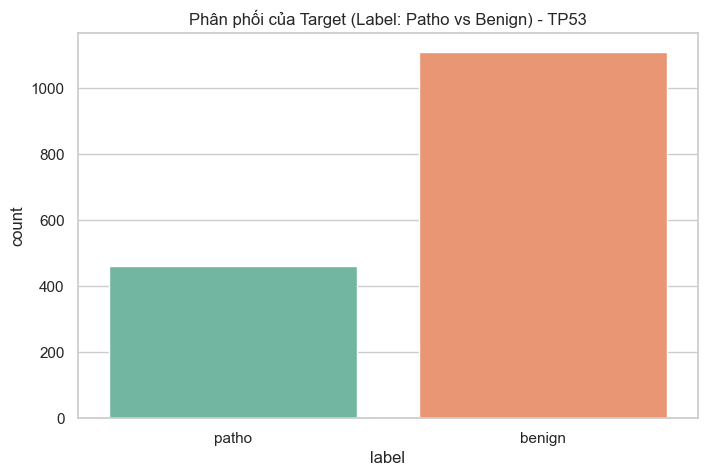

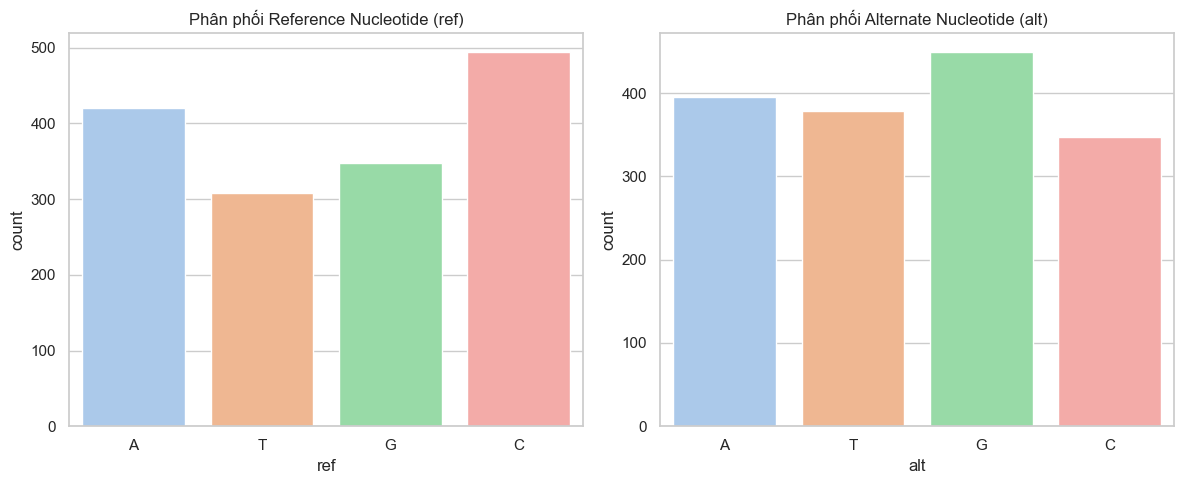

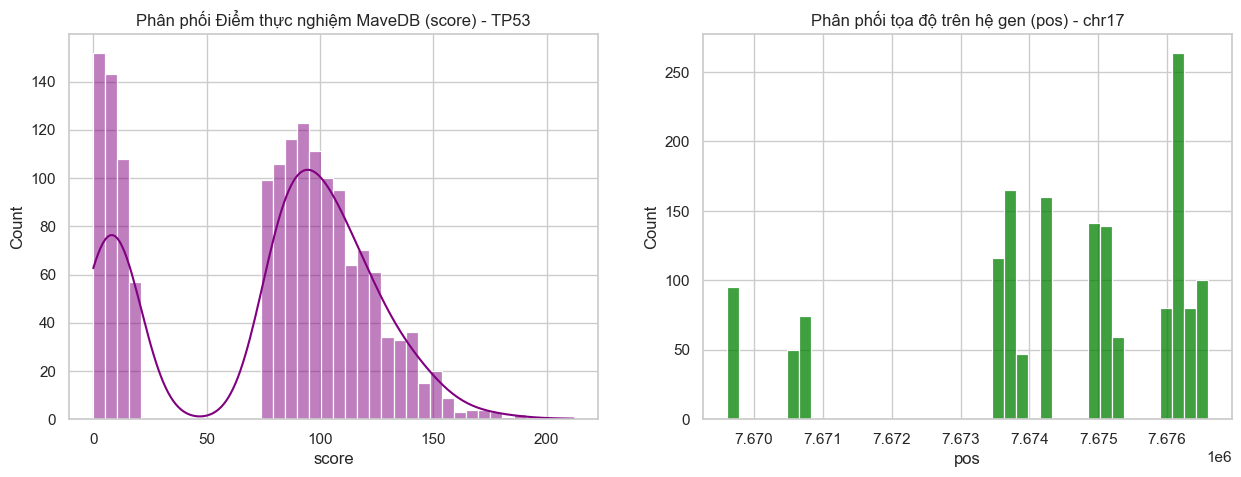


4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI TRÊN ĐIỂM SỐ)


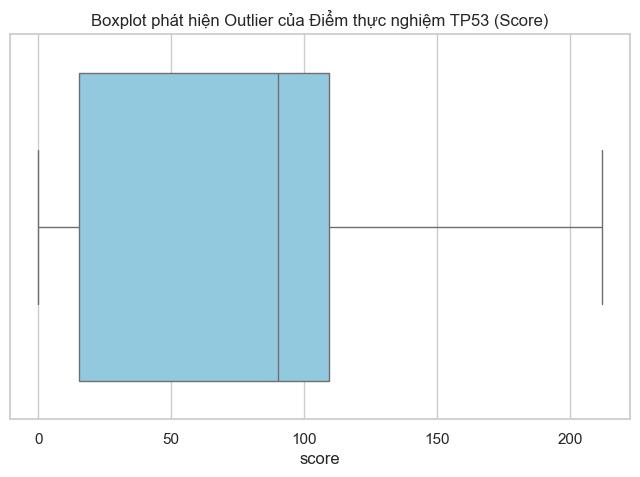

Số lượng Outliers theo IQR (score): 0
Số lượng Outliers theo Z-score > 3 (score): 0

5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)


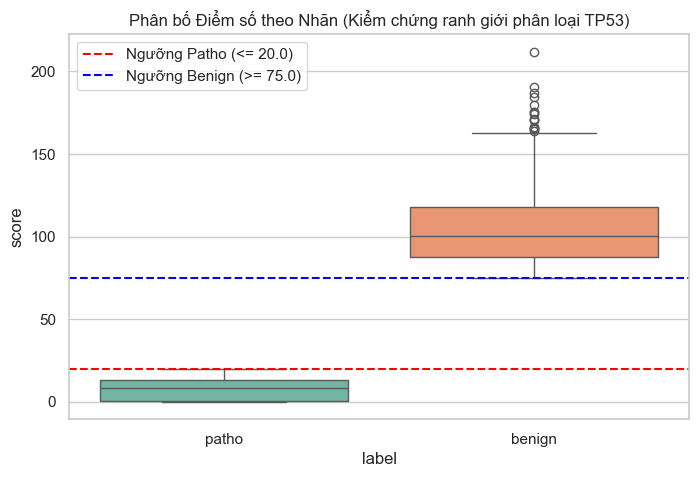

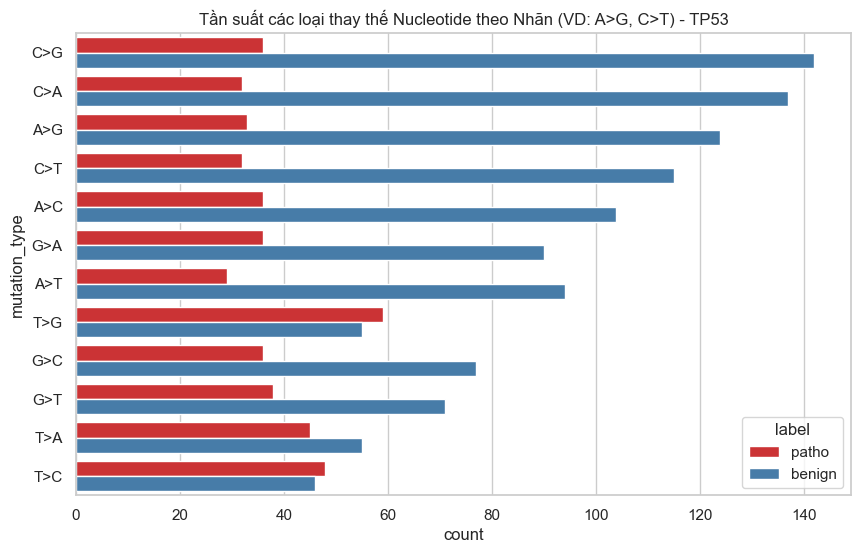


6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)


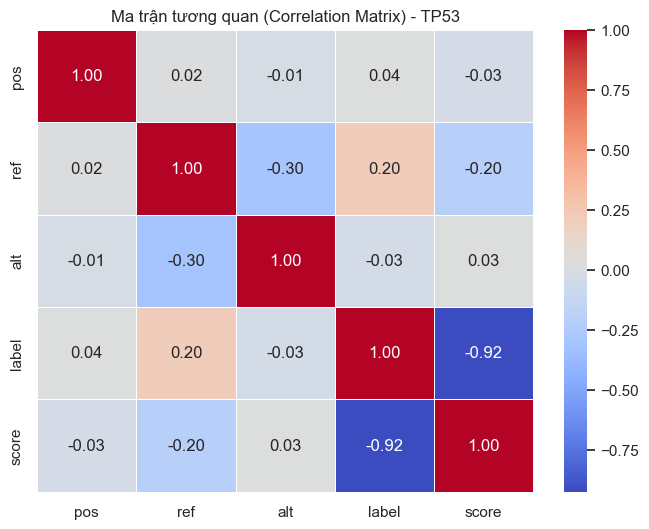


7. THỐNG KÊ TỶ LỆ PATHOGENIC THEO VỊ TRÍ (HOTSPOT ANALYSIS)
- Tỷ lệ đột biến Gây bệnh (Pathogenic) tổng thể của TP53: 29.30%
- Thống kê số lượng đột biến theo từng vị trí (Phát hiện Hotspot):
pos
7673701    3
7673549    3
7673548    3
7675236    3
7675124    3
7675125    3
7676151    3
7674289    3
7674872    3
7674873    3
Name: count, dtype: int64

8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN CHO AITA LAB)

[GÓC NHÌN ĐÁNH GIÁ MODEL CỦA NHÓM]:
- Kiểm chứng Dịch ngược (Reverse Mapping): So với BRCA2, TP53 được dịch ngược từ protein sang DNA, nên số lượng dòng trùng lặp (duplicates) ở tọa độ (pos) có thể cao hơn do nhiều codon cùng quy định một axit amin. Hotspot analysis (Phần 7) sẽ làm rõ điều này.
- Phân tách khoảng trống (Boxplot phần 5): Khoảng cách từ 20.0 đến 75.0 là một khoảng trống rất lớn (vùng partially functional). Đồ thị sẽ cho thấy sự phân ly rõ rệt, chứng tỏ tập dữ liệu TP53 này rất "sạch" và khắt khe để test độ nhạy (Sensitivity) của mô hình.
- Ứng dụng thực tế: TP53 là gen 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Đang nạp dữ liệu TP53...")
# Nhớ điều chỉnh lại đường dẫn cho khớp với máy của bạn
df = pd.read_csv(r"TP53_Final_Dataset.csv")

# Đảm bảo cột pos và score là dạng số
df['pos'] = pd.to_numeric(df['pos'], errors='coerce')
df['score'] = pd.to_numeric(df['score'], errors='coerce')

print("\n" + "="*50)
print("1. DATASET OVERVIEW (TỔNG QUAN)")
print("="*50)
print(f"Shape (Số dòng, Số cột): {df.shape}")
print("\nDanh sách các cột (Columns):")
print(df.columns.tolist())
print("\nKiểu dữ liệu (Data types):")
print(df.dtypes)
print("\nSố lượng giá trị duy nhất (Unique values):")
print(df.nunique())

print("\n" + "="*50)
print("2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)")
print("="*50)
print("Số lượng Missing values ở mỗi cột:")
print(df.isnull().sum())
print(f"\nSố lượng dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

print("\n" + "="*50)
print("3. UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)")
print("="*50)
# 3.1 Target Distribution (Phân phối nhãn)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Phân phối của Target (Label: Patho vs Benign) - TP53')
plt.show()

# 3.2 Categorical Distribution (Phân phối Nucleotide)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='ref', ax=axes[0], palette='pastel', order=['A', 'T', 'G', 'C'])
axes[0].set_title('Phân phối Reference Nucleotide (ref)')

sns.countplot(data=df, x='alt', ax=axes[1], palette='pastel', order=['A', 'T', 'G', 'C'])
axes[1].set_title('Phân phối Alternate Nucleotide (alt)')
plt.tight_layout()
plt.show()

# 3.3 Numerical distribution (Phân phối điểm số thực nghiệm và Tọa độ)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['score'], bins=40, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Phân phối Điểm thực nghiệm MaveDB (score) - TP53')

sns.histplot(df['pos'], bins=40, kde=False, ax=axes[1], color='green')
axes[1].set_title('Phân phối tọa độ trên hệ gen (pos) - chr17')
plt.show()

print("\n" + "="*50)
print("4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI TRÊN ĐIỂM SỐ)")
print("="*50)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['score'], color='skyblue')
plt.title('Boxplot phát hiện Outlier của Điểm thực nghiệm TP53 (Score)')
plt.show()

# Tính IQR & Z-score cho score
Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['score'] < lower_bound) | (df['score'] > upper_bound)]
print(f"Số lượng Outliers theo IQR (score): {len(outliers_iqr)}")

z_scores = np.abs(stats.zscore(df['score'].dropna()))
outliers_z = len(np.where(z_scores > 3)[0])
print(f"Số lượng Outliers theo Z-score > 3 (score): {outliers_z}")

print("\n" + "="*50)
print("5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)")
print("="*50)
# Numerical ↔ Categorical (score vs label) -> Kiểm chứng lại ranh giới
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='score', palette='Set2')
plt.axhline(20.0, color='red', linestyle='--', label='Ngưỡng Patho (<= 20.0)')
plt.axhline(75.0, color='blue', linestyle='--', label='Ngưỡng Benign (>= 75.0)')
plt.title('Phân bố Điểm số theo Nhãn (Kiểm chứng ranh giới phân loại TP53)')
plt.legend()
plt.show()

# Categorical ↔ Categorical (Sự thay đổi Ref -> Alt)
plt.figure(figsize=(10, 6))
mutation_types = df['ref'] + ">" + df['alt']
df['mutation_type'] = mutation_types
sns.countplot(data=df, y='mutation_type', hue='label', palette='Set1', order=df['mutation_type'].value_counts().index)
plt.title('Tần suất các loại thay thế Nucleotide theo Nhãn (VD: A>G, C>T) - TP53')
plt.show()

print("\n" + "="*50)
print("6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)")
print("="*50)
# Label Encoding các biến categorical
df_encoded = df[['pos', 'ref', 'alt', 'label', 'score']].copy()
for col in ['ref', 'alt', 'label']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr_matrix = df_encoded.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Matrix) - TP53')
plt.show()

print("\n" + "="*50)
print("7. THỐNG KÊ TỶ LỆ PATHOGENIC THEO VỊ TRÍ (HOTSPOT ANALYSIS)")
print("="*50)
patho_ratio = (df['label'] == 'patho').mean() * 100
print(f"- Tỷ lệ đột biến Gây bệnh (Pathogenic) tổng thể của TP53: {patho_ratio:.2f}%")
print("- Thống kê số lượng đột biến theo từng vị trí (Phát hiện Hotspot):")
hotspots = df['pos'].value_counts().head(10)
print(hotspots)

print("\n" + "="*50)
print("8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN CHO AITA LAB)")
print("="*50)
print("""
[GÓC NHÌN ĐÁNH GIÁ MODEL CỦA NHÓM]:
- Kiểm chứng Dịch ngược (Reverse Mapping): So với BRCA2, TP53 được dịch ngược từ protein sang DNA, nên số lượng dòng trùng lặp (duplicates) ở tọa độ (pos) có thể cao hơn do nhiều codon cùng quy định một axit amin. Hotspot analysis (Phần 7) sẽ làm rõ điều này.
- Phân tách khoảng trống (Boxplot phần 5): Khoảng cách từ 20.0 đến 75.0 là một khoảng trống rất lớn (vùng partially functional). Đồ thị sẽ cho thấy sự phân ly rõ rệt, chứng tỏ tập dữ liệu TP53 này rất "sạch" và khắt khe để test độ nhạy (Sensitivity) của mô hình.
- Ứng dụng thực tế: TP53 là gen ức chế khối u quan trọng nhất. Nếu các mô hình như NTv3 hay EVO2 đạt điểm MCC cao trên tập OOD này, đây sẽ là một minh chứng xuất sắc để đưa vào bài báo cáo.
""")